# T/NK Cell Annotation - Post-annotation (3-Category)

**Your Annotation**: T, NK, Low_quality (粗标注)

**Workflow**:
1. Load T/NK dataset
2. Apply your 3-category annotations
3. Generate visualizations
4. **Subset pure T cells** (remove NK and Low_quality)
5. Save datasets

**Output**:
- Full annotated dataset (T + NK + Low_quality)
- **Pure T cell dataset** → for downstream scVI re-integration and fine annotation

---
## Step 1: Import Libraries

In [1]:
import sys
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import scanpy as sc

warnings.filterwarnings('ignore')

print(f"scanpy: {sc.__version__}")
print(f"Python: {sys.version}")

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
plt.rcParams['figure.figsize'] = (8, 6)

print("\n✓ Libraries loaded")

scanpy: 1.9.8
Python: 3.9.24 (main, Oct 21 2025, 20:11:42) 
[GCC 11.2.0]

✓ Libraries loaded


---
## Step 2: Configuration

In [2]:
# ==================== Configuration ====================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Input/Output
INPUT_H5AD = "/home/h2048/data/py/1203/T_scvi_integration/adata_tcell_scvi_full.h5ad"
ANNOTATION_DIR = "/home/h2048/data/py/1204/TNK_major_annotation"
OUTPUT_DIR = "/home/h2048/data/py/1204/TNK_annotated"

ANNOTATION_FILE = "Annotation.csv"  # Format: Cluster,CellType (NO header)
RESOLUTION = "default"

# Cell types to REMOVE (keep only 'T' cells)
# Your annotation: T, NK, Low_quality
REMOVE_CELL_TYPES = ['NK', 'Low_quality', 'Unknown']

# Visualization
DPI = 300
FIGURE_FORMAT = "pdf"

# Colors for your 3 categories
CELL_TYPE_COLORS = {
    'T': '#4DAF4A',           # Green
    'NK': '#e377c2',          # Pink
    'Low_quality': '#bcbd22', # Yellow-green
    'Unknown': '#7f7f7f'      # Gray
}

# Create directories
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)
fig_dir = output_dir / "figures"
fig_dir.mkdir(exist_ok=True)

print("\n✓ Configuration loaded")
print(f"  Input: {INPUT_H5AD}")
print(f"  Annotations: {Path(ANNOTATION_DIR) / ANNOTATION_FILE}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Will KEEP: T cells only")
print(f"  Will REMOVE: {REMOVE_CELL_TYPES}")


✓ Configuration loaded
  Input: /home/h2048/data/py/1203/T_scvi_integration/adata_tcell_scvi_full.h5ad
  Annotations: /home/h2048/data/py/1204/TNK_major_annotation/Annotation.csv
  Output: /home/h2048/data/py/1204/TNK_annotated
  Will KEEP: T cells only
  Will REMOVE: ['NK', 'Low_quality', 'Unknown']


---
## Step 3: Load Data and Resolve Clustering

In [3]:
print("\n" + "="*70)
print("Step 3: Loading Data")
print("="*70)

# Load
adata = sc.read_h5ad(INPUT_H5AD)
print(f"\nLoaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")

# Resolve cluster key
def resolve_cluster_key(adata, resolution):
    if resolution == "default":
        for key in ['leiden', 'leiden_bbknn', 'leiden_scvi', 'clusters']:
            if key in adata.obs.columns:
                return key
        leiden_cols = [c for c in adata.obs.columns if 'leiden' in c.lower()]
        if leiden_cols:
            return leiden_cols[0]
        raise ValueError("No clustering column found")
    else:
        res_str = str(resolution)
        for key in [f'leiden_res{res_str}', f'leiden_bbknn_res{res_str}']:
            if key in adata.obs.columns:
                return key
        raise ValueError(f"No column for resolution {resolution}")

cluster_key = resolve_cluster_key(adata, RESOLUTION)
print(f"\n✓ Cluster column: '{cluster_key}'")
print(f"  Clusters: {adata.obs[cluster_key].nunique()}")


Step 3: Loading Data

Loaded: 45,676 cells × 34,252 genes

✓ Cluster column: 'leiden'
  Clusters: 48


---
## Step 4: Load and Apply Annotations

In [4]:
print("\n" + "="*70)
print("Step 4: Applying Annotations")
print("="*70)

# Load annotation file
annotation_path = Path(ANNOTATION_DIR) / ANNOTATION_FILE

if not annotation_path.exists():
    raise FileNotFoundError(f"\nAnnotation file not found: {annotation_path}")

print(f"\nLoading: {annotation_path}")

# Read (no header)
annotation_df = pd.read_csv(
    annotation_path,
    header=None,
    names=['Cluster', 'CellType'],
    dtype={'Cluster': str, 'CellType': str},
    encoding='utf-8'
)

print(f"  ✓ Loaded {len(annotation_df)} annotations")

# Display
print(f"\nYour 3-category annotation:")
for celltype, count in annotation_df['CellType'].value_counts().items():
    print(f"  {celltype}: {count} clusters")

# Create mapping
cluster_to_celltype = dict(zip(
    annotation_df['Cluster'].astype(str),
    annotation_df['CellType']
))

# Apply
adata.obs[cluster_key] = adata.obs[cluster_key].astype(str)
adata.obs['cell_type'] = adata.obs[cluster_key].map(cluster_to_celltype).fillna('Unknown')

# Summary
print(f"\n✓ Annotations applied")
print(f"\nCell distribution:")
for ct, count in adata.obs['cell_type'].value_counts().items():
    pct = count / len(adata) * 100
    print(f"  {ct}: {count:,} cells ({pct:.1f}%)")

print("\n✓ Complete")


Step 4: Applying Annotations

Loading: /home/h2048/data/py/1204/TNK_major_annotation/Annotation.csv
  ✓ Loaded 48 annotations

Your 3-category annotation:
  T: 33 clusters
  NK: 14 clusters
  Low_quality: 1 clusters

✓ Annotations applied

Cell distribution:
  T: 32,731 cells (71.7%)
  NK: 12,890 cells (28.2%)
  Low_quality: 55 cells (0.1%)

✓ Complete


---
## Step 5: Visualizations

In [5]:
print("\n" + "="*70)
print("Step 5: Generating Visualizations")
print("="*70)

has_umap = 'X_umap' in adata.obsm
if not has_umap:
    print("\n⚠️  UMAP not found, computing...")
    if 'X_scvi' in adata.obsm:
        sc.pp.neighbors(adata, use_rep='X_scvi')
    else:
        sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    print("  ✓ UMAP computed")

print("\nCreating plots...")


Step 5: Generating Visualizations

Creating plots...


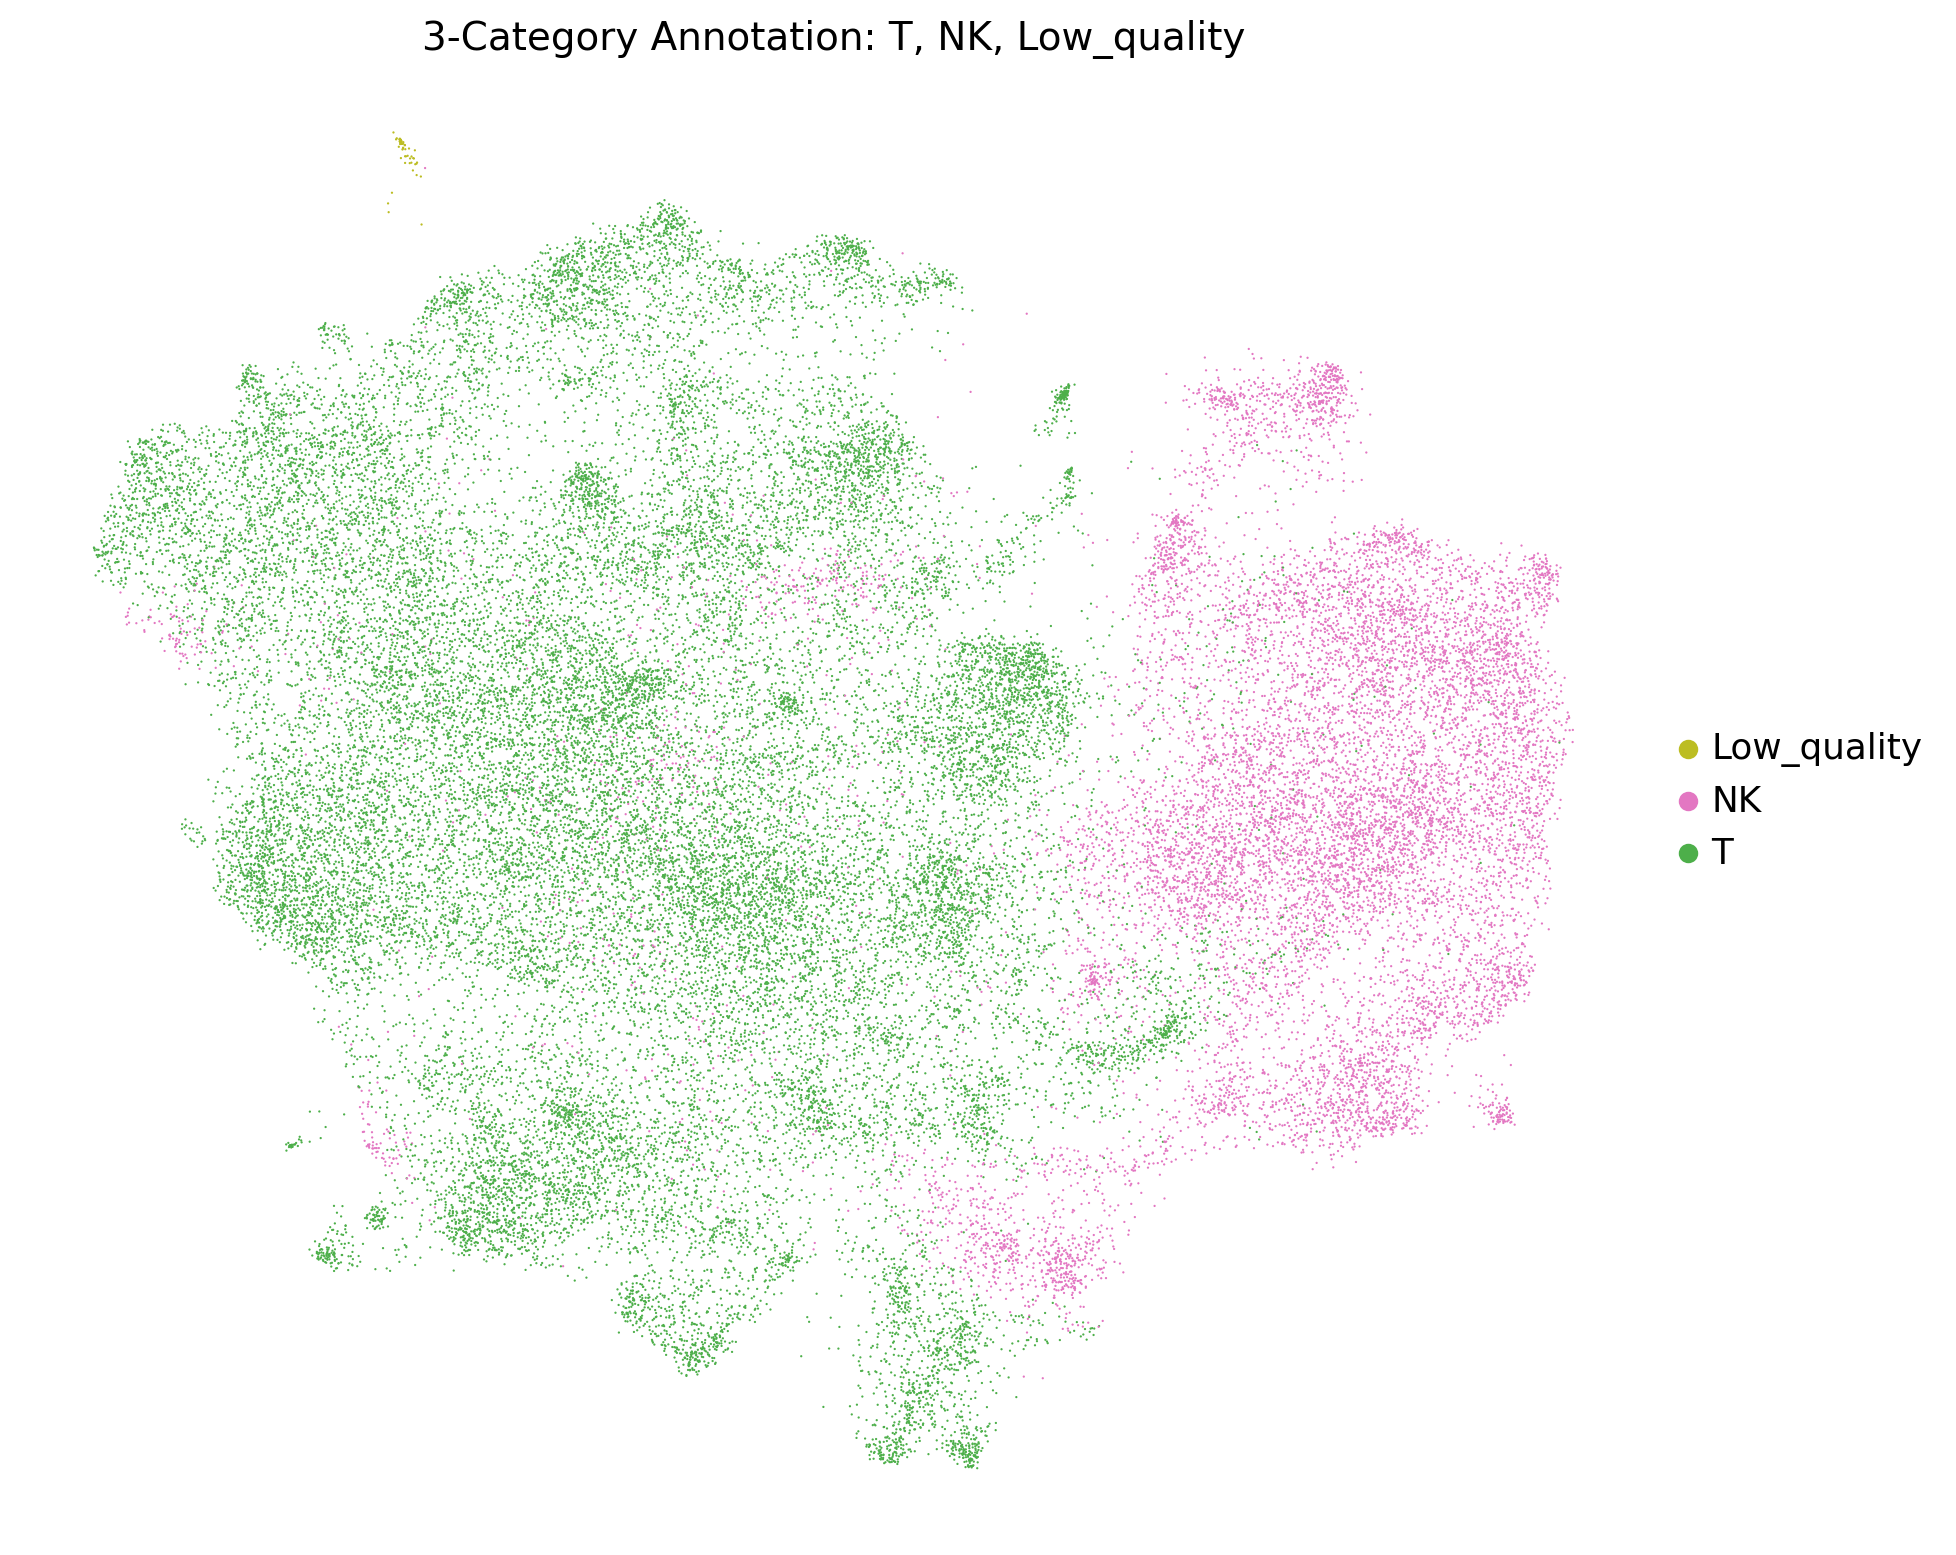

✓ Plot 1: 3-category UMAP


In [6]:
# 1. Main cell type UMAP
fig, ax = plt.subplots(figsize=(10, 8))

sc.pl.umap(
    adata,
    color='cell_type',
    palette=CELL_TYPE_COLORS,
    ax=ax,
    show=False,
    legend_loc='right margin',
    frameon=False,
    title='3-Category Annotation: T, NK, Low_quality'
)

plt.tight_layout()
plt.savefig(fig_dir / f'umap_3category.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Plot 1: 3-category UMAP")

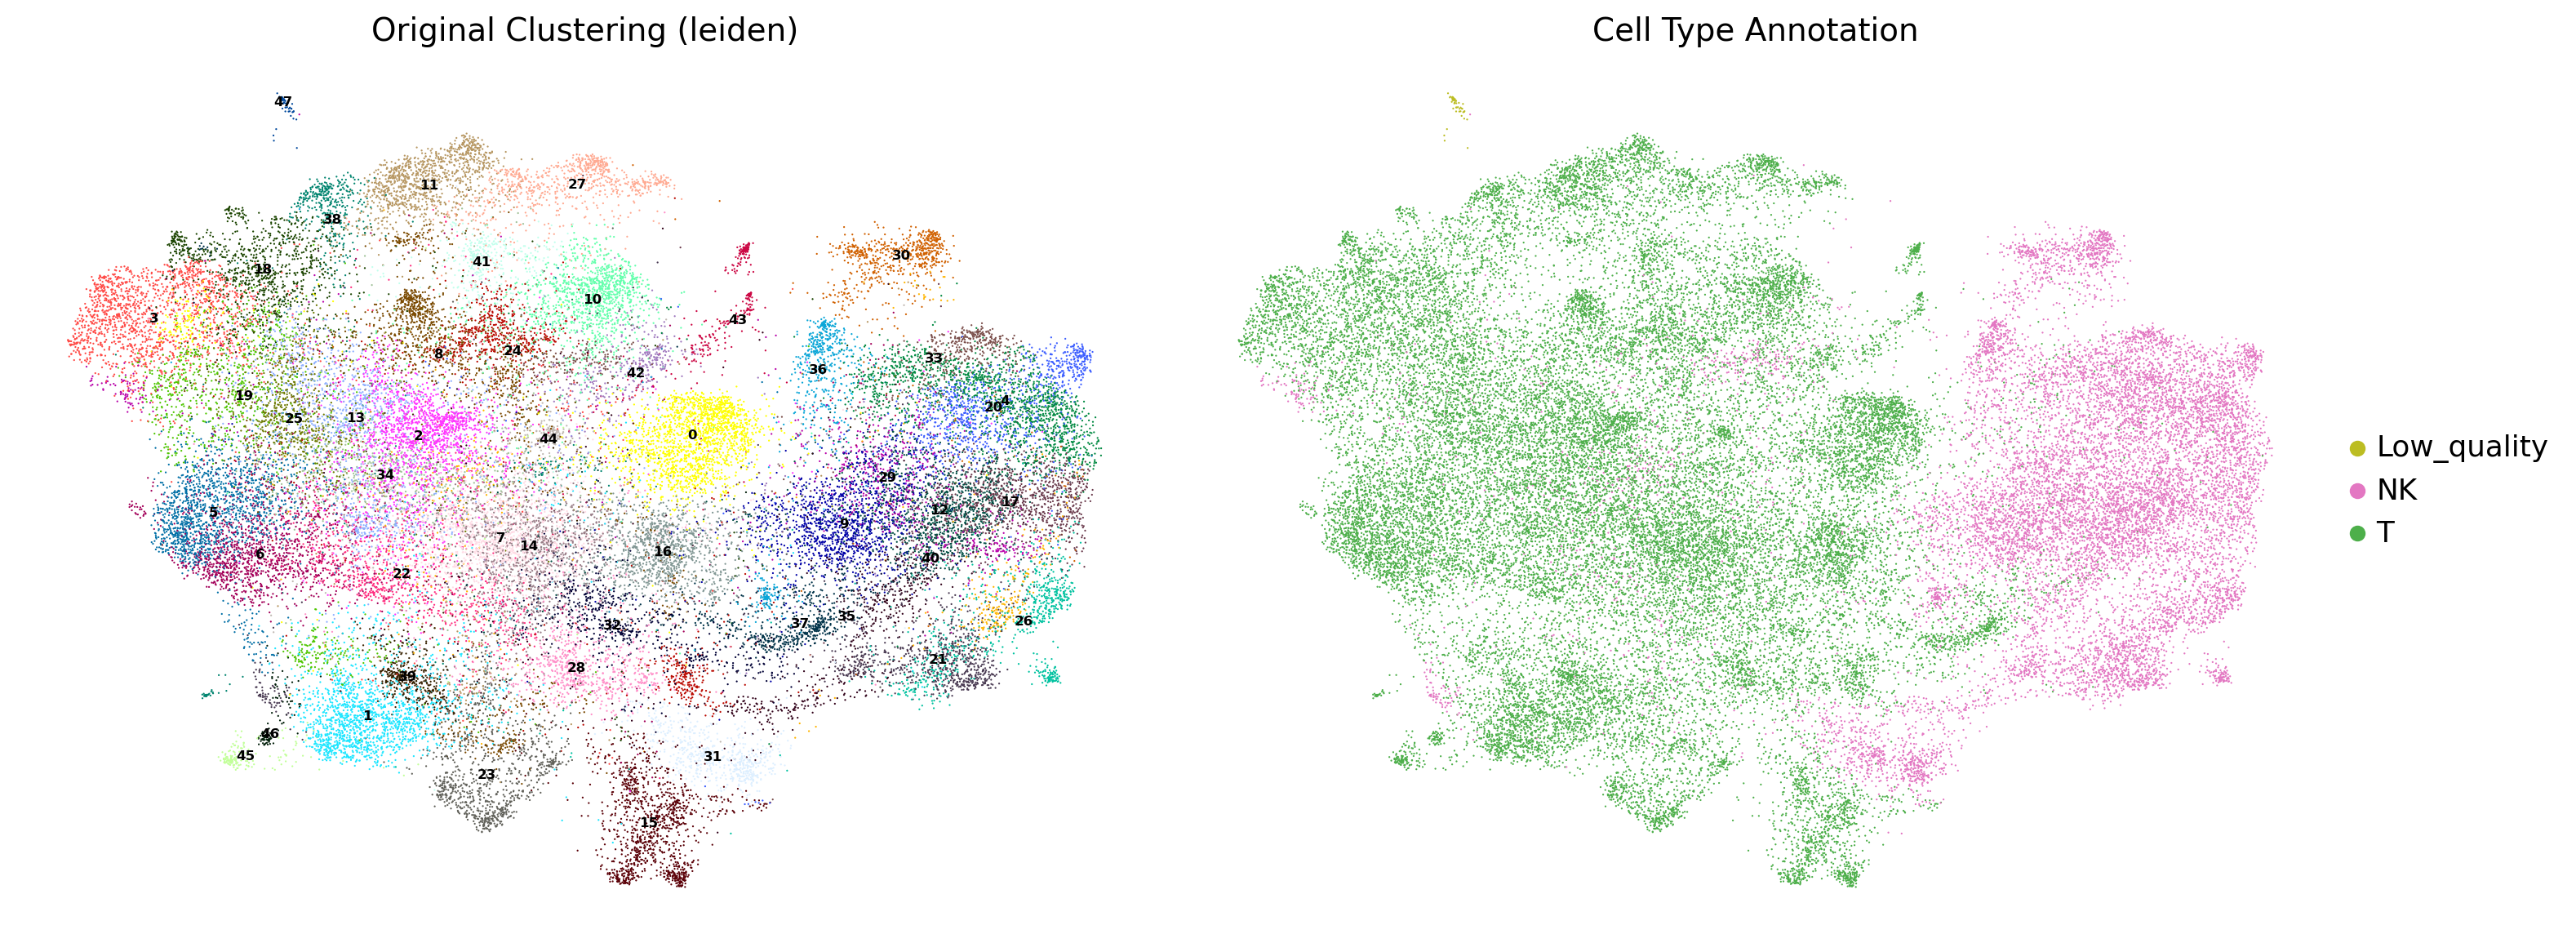

✓ Plot 2: Clustering vs annotation


In [7]:
# 2. Original clustering vs annotation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(
    adata,
    color=cluster_key,
    ax=axes[0],
    show=False,
    legend_loc='on data',
    legend_fontsize=6,
    frameon=False,
    title=f'Original Clustering ({cluster_key})'
)

sc.pl.umap(
    adata,
    color='cell_type',
    palette=CELL_TYPE_COLORS,
    ax=axes[1],
    show=False,
    legend_loc='right margin',
    frameon=False,
    title='Cell Type Annotation'
)

plt.tight_layout()
plt.savefig(fig_dir / f'umap_cluster_vs_celltype.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Plot 2: Clustering vs annotation")

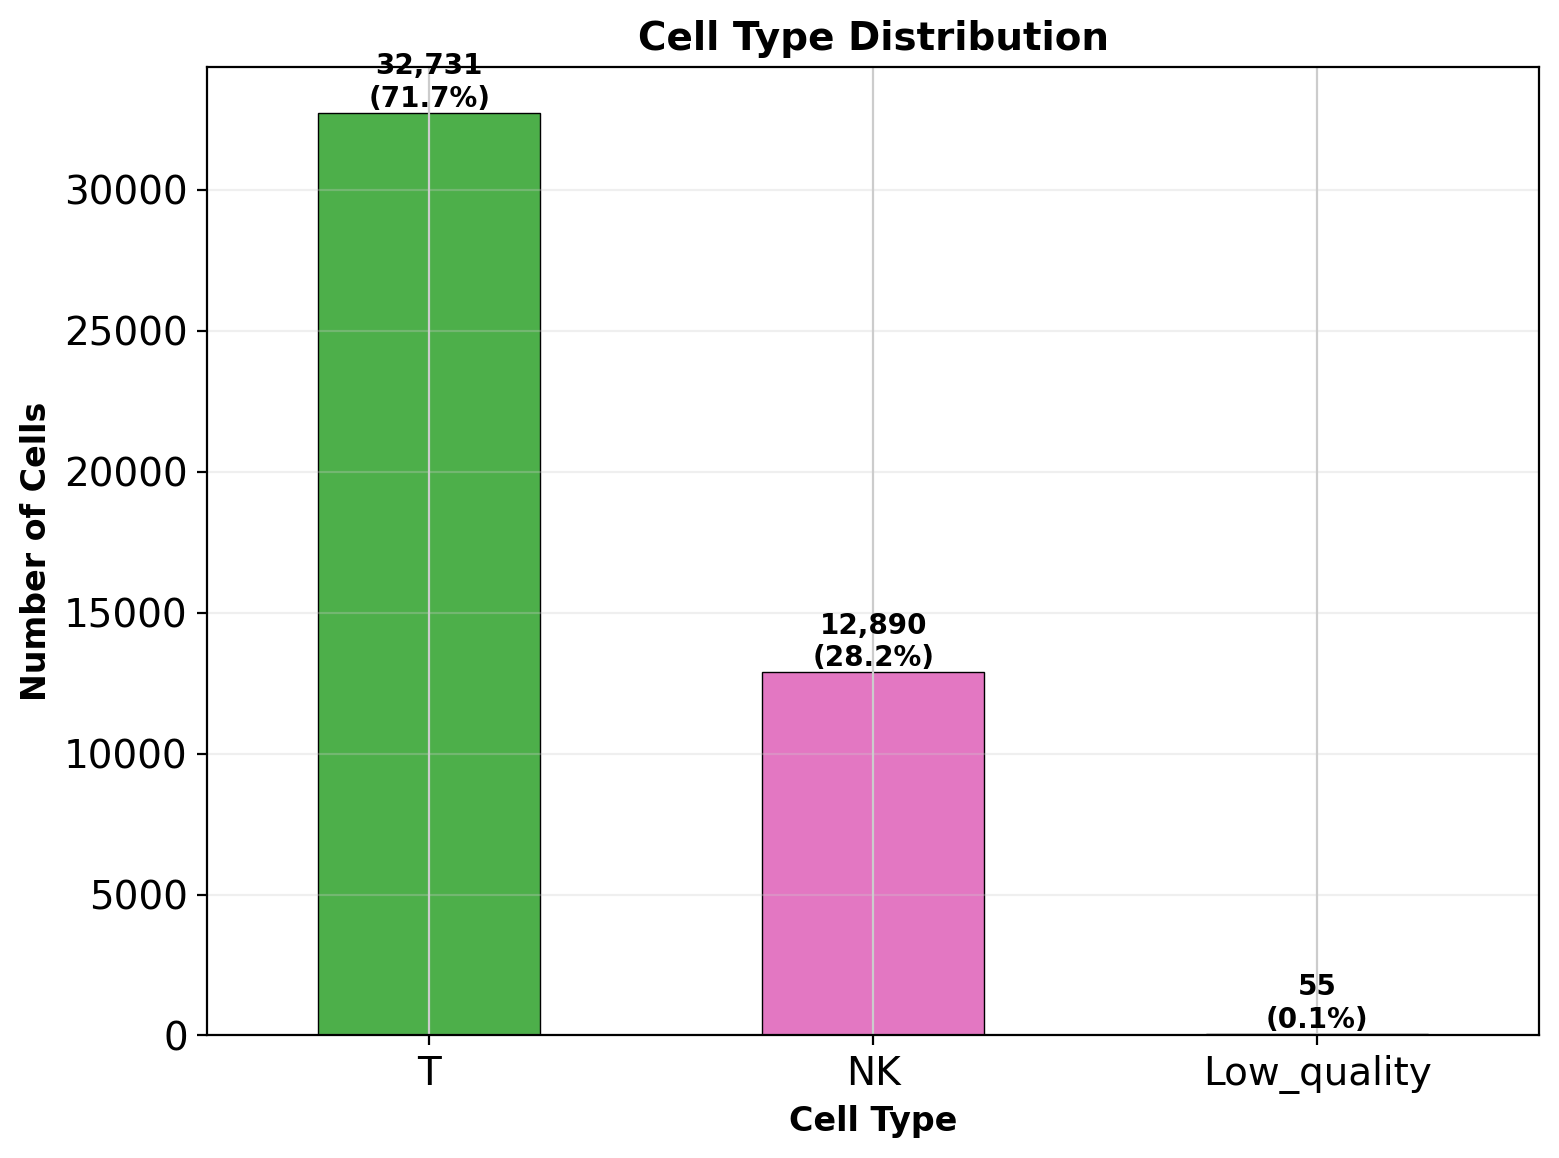

✓ Plot 3: Distribution bar plot

✓ All visualizations complete


In [8]:
# 3. Distribution bar plot
fig, ax = plt.subplots(figsize=(8, 6))

counts = adata.obs['cell_type'].value_counts()
colors = [CELL_TYPE_COLORS.get(ct, '#999999') for ct in counts.index]

counts.plot.bar(ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Cells', fontsize=12, fontweight='bold')
ax.set_title('Cell Type Distribution', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

for i, (ct, count) in enumerate(counts.items()):
    pct = count / len(adata) * 100
    ax.text(i, count, f'{count:,}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_dir / f'barplot_distribution.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Plot 3: Distribution bar plot")
print("\n✓ All visualizations complete")

---
## Step 6: Subset Pure T Cells

In [9]:
print("\n" + "="*70)
print("Step 6: Subsetting Pure T Cells")
print("="*70)

print(f"\nFiltering strategy:")
print(f"  KEEP: cells labeled as 'T'")
print(f"  REMOVE: {REMOVE_CELL_TYPES}")

# Create mask: keep only 'T' cells
keep_mask = ~adata.obs['cell_type'].isin(REMOVE_CELL_TYPES)

# Subset
adata_tcell = adata[keep_mask].copy()

print(f"\n{'='*70}")
print("Subsetting Results:")
print(f"{'='*70}")
print(f"  Original: {len(adata):,} cells")

for ct in REMOVE_CELL_TYPES:
    n = (adata.obs['cell_type'] == ct).sum()
    if n > 0:
        print(f"  Removed '{ct}': {n:,} cells ({n/len(adata)*100:.1f}%)")

print(f"\n  ✓ Pure T cells: {len(adata_tcell):,} cells")
print(f"  Retention rate: {len(adata_tcell)/len(adata)*100:.1f}%")
print(f"{'='*70}")

# Verify
unique_types = adata_tcell.obs['cell_type'].unique()
print(f"\n✓ Verification - cell types in T cell dataset: {list(unique_types)}")
if set(unique_types) != {'T'}:
    print(f"  ⚠️  Warning: Expected only 'T', found: {list(unique_types)}")

print("\n✓ Subset complete")


Step 6: Subsetting Pure T Cells

Filtering strategy:
  KEEP: cells labeled as 'T'
  REMOVE: ['NK', 'Low_quality', 'Unknown']

Subsetting Results:
  Original: 45,676 cells
  Removed 'NK': 12,890 cells (28.2%)
  Removed 'Low_quality': 55 cells (0.1%)

  ✓ Pure T cells: 32,731 cells
  Retention rate: 71.7%

✓ Verification - cell types in T cell dataset: ['T']

✓ Subset complete


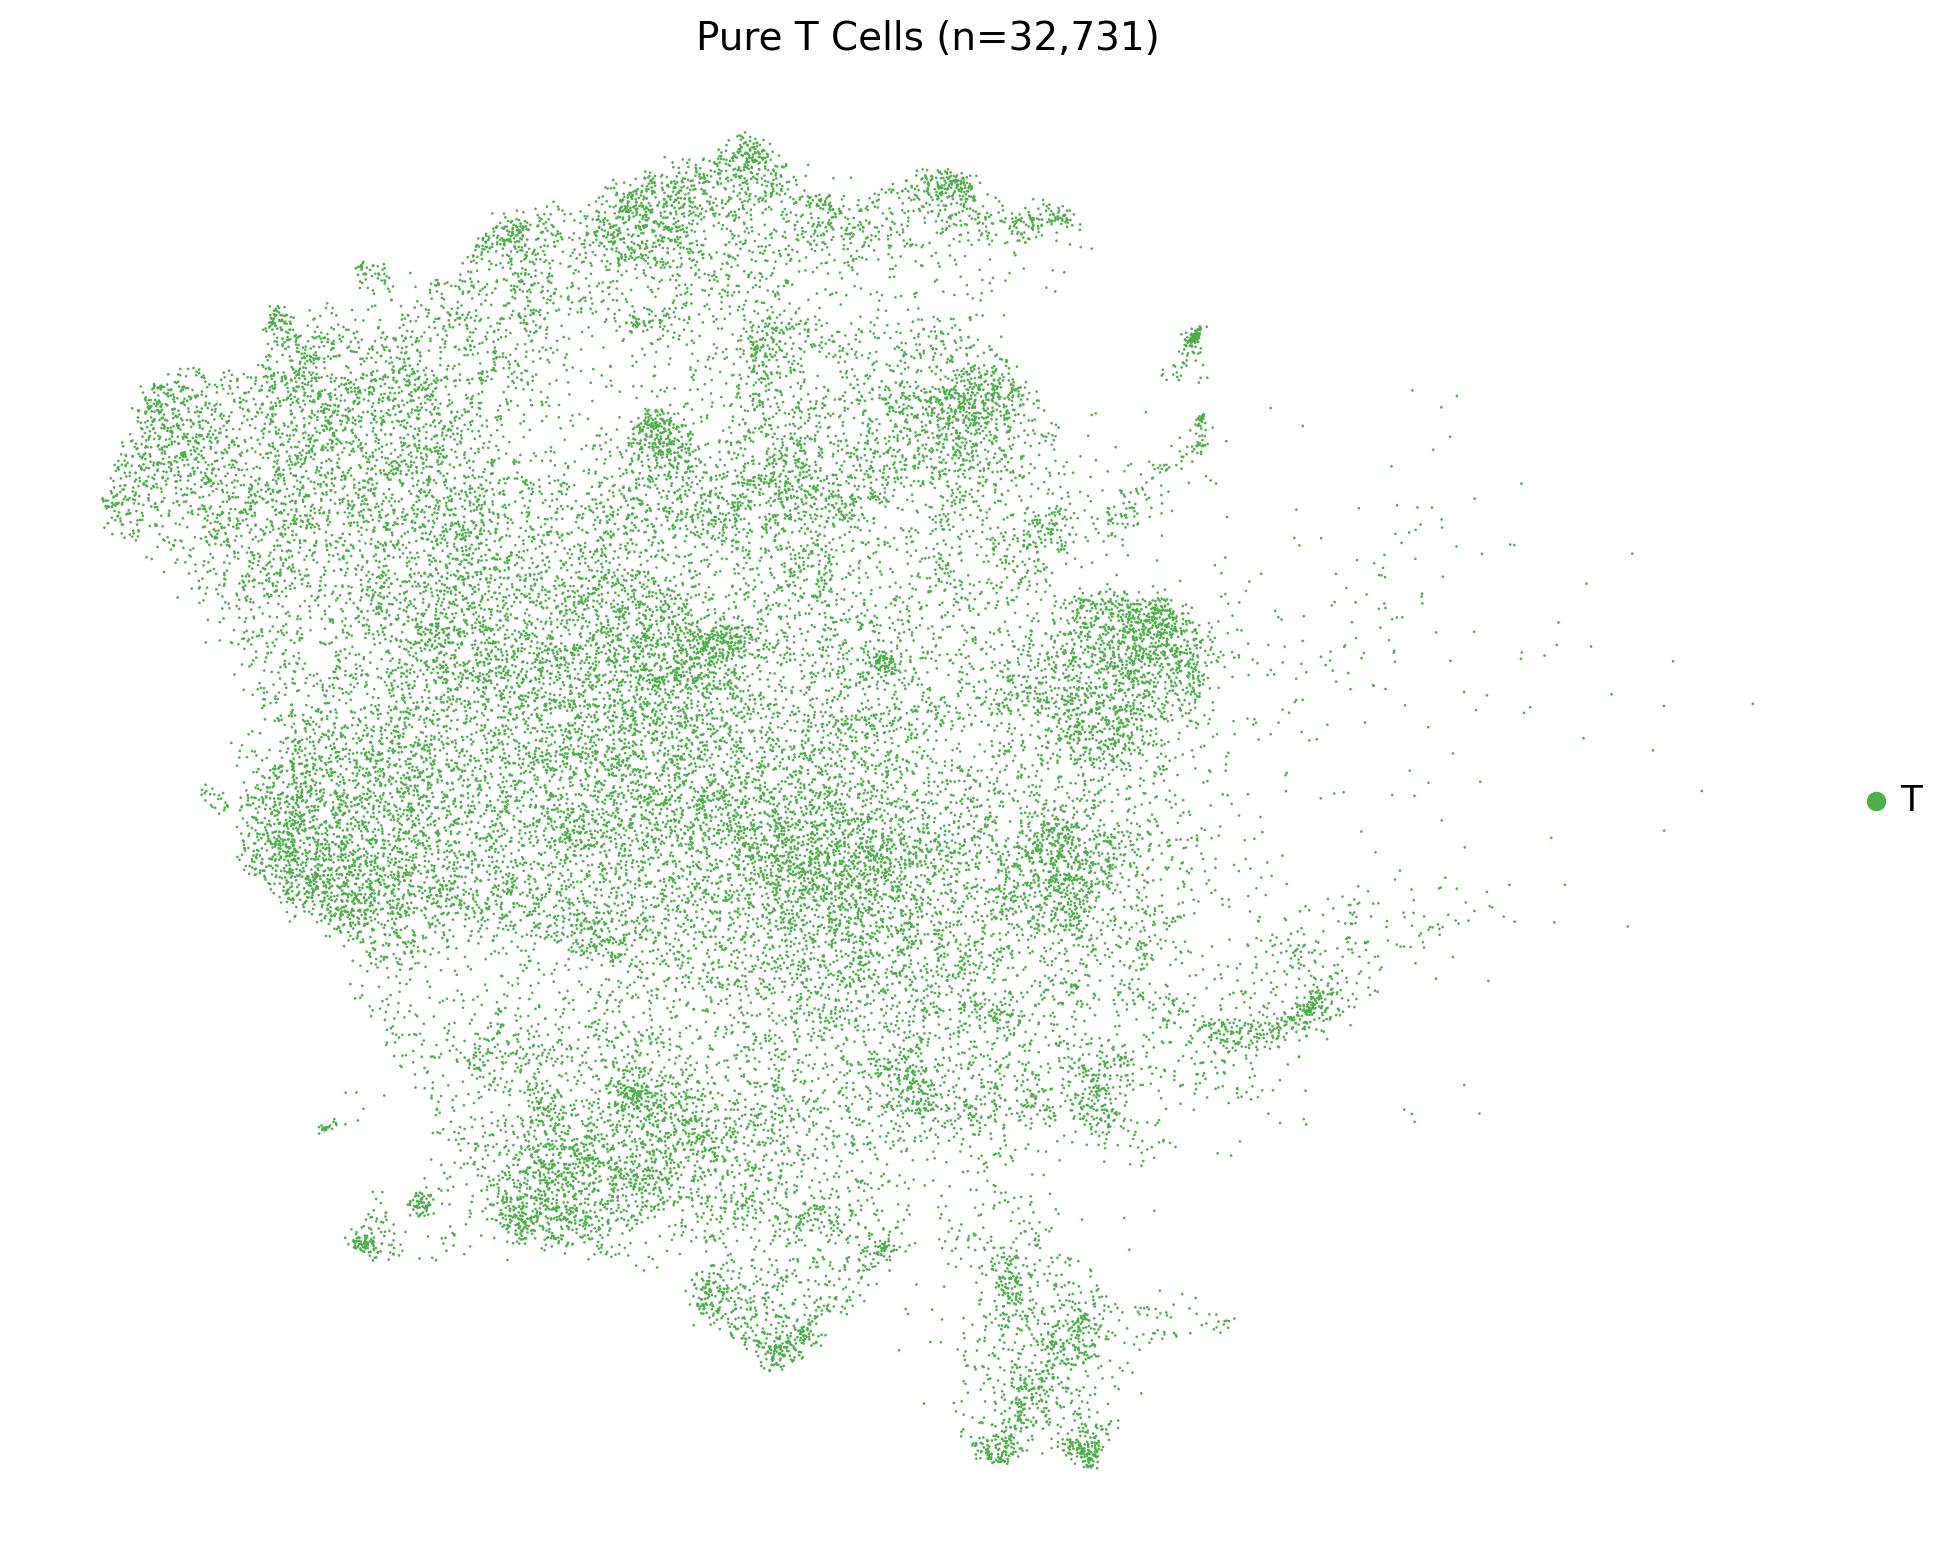

✓ T cell UMAP saved


In [10]:
# Visualize T cells
fig, ax = plt.subplots(figsize=(10, 8))

sc.pl.umap(
    adata_tcell,
    color='cell_type',
    palette=CELL_TYPE_COLORS,
    ax=ax,
    show=False,
    legend_loc='right margin',
    frameon=False,
    title=f'Pure T Cells (n={len(adata_tcell):,})'
)

plt.tight_layout()
plt.savefig(fig_dir / f'umap_tcell_pure.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ T cell UMAP saved")

---
## Step 7: Save Datasets

In [11]:
print("\n" + "="*70)
print("Step 7: Saving Datasets")
print("="*70)

# 1. Full annotated dataset
output_full = output_dir / "adata_TNK_annotated.h5ad"
print(f"\n1. Saving full T/NK dataset...")
adata.write_h5ad(output_full, compression='gzip', compression_opts=9)
print(f"   ✓ {output_full}")
print(f"   Size: {output_full.stat().st_size / 1024**2:.1f} MB")
print(f"   Cells: {len(adata):,} (T + NK + Low_quality)")

# 2. Pure T cell dataset
output_tcell = output_dir / "adata_Tcell_pure.h5ad"
print(f"\n2. Saving pure T cell dataset...")
adata_tcell.write_h5ad(output_tcell, compression='gzip', compression_opts=9)
print(f"   ✓ {output_tcell}")
print(f"   Size: {output_tcell.stat().st_size / 1024**2:.1f} MB")
print(f"   Cells: {len(adata_tcell):,} (pure T cells)")

# 3. Summary CSV
summary_file = output_dir / "celltype_summary.csv"
summary_df = pd.DataFrame({
    'CellType': adata.obs['cell_type'].value_counts().index,
    'n_cells': adata.obs['cell_type'].value_counts().values,
    'percentage': adata.obs['cell_type'].value_counts().values / len(adata) * 100
})
summary_df.to_csv(summary_file, index=False, encoding='utf-8')
print(f"\n3. Cell type summary: {summary_file}")

# 4. Metadata
metadata_file = output_dir / "annotation_metadata.txt"
with open(metadata_file, 'w') as f:
    f.write("T/NK Cell 3-Category Annotation\n")
    f.write("="*70 + "\n\n")
    f.write(f"Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("Input:\n")
    f.write(f"  Data: {INPUT_H5AD}\n")
    f.write(f"  Annotations: {annotation_path}\n")
    f.write(f"  Clustering: {cluster_key}\n\n")
    
    f.write("Annotation Categories:\n")
    f.write(f"  T, NK, Low_quality (3 categories)\n\n")
    
    f.write("Cell Distribution:\n")
    for ct, count in adata.obs['cell_type'].value_counts().items():
        pct = count / len(adata) * 100
        f.write(f"  {ct}: {count:,} cells ({pct:.1f}%)\n")
    
    f.write(f"\nT Cell Subsetting:\n")
    f.write(f"  Pure T cells: {len(adata_tcell):,}\n")
    f.write(f"  Retention rate: {len(adata_tcell)/len(adata)*100:.1f}%\n\n")
    
    f.write(f"Output Files:\n")
    f.write(f"  Full: {output_full}\n")
    f.write(f"  Pure T: {output_tcell} (for scVI re-integration)\n")
    f.write(f"  Figures: {fig_dir}/*.{FIGURE_FORMAT}\n")

print(f"\n4. Metadata: {metadata_file}")
print("\n✓ All files saved")


Step 7: Saving Datasets

1. Saving full T/NK dataset...
   ✓ /home/h2048/data/py/1204/TNK_annotated/adata_TNK_annotated.h5ad
   Size: 603.5 MB
   Cells: 45,676 (T + NK + Low_quality)

2. Saving pure T cell dataset...
   ✓ /home/h2048/data/py/1204/TNK_annotated/adata_Tcell_pure.h5ad
   Size: 446.0 MB
   Cells: 32,731 (pure T cells)

3. Cell type summary: /home/h2048/data/py/1204/TNK_annotated/celltype_summary.csv

4. Metadata: /home/h2048/data/py/1204/TNK_annotated/annotation_metadata.txt

✓ All files saved


---
## Step 8: Summary

In [12]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"\nCompleted: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n{'='*70}")
print("3-Category Annotation Applied:")
print(f"{'='*70}")
for ct, count in adata.obs['cell_type'].value_counts().items():
    pct = count / len(adata) * 100
    print(f"  {ct}: {count:,} cells ({pct:.1f}%)")

print(f"\n{'='*70}")
print("Key Output Files:")
print(f"{'='*70}")
print(f"\n1. Pure T cells (for scVI re-integration):")
print(f"   {output_tcell}")
print(f"   → Use this for downstream T cell fine annotation")

print(f"\n2. Full annotated (reference):")
print(f"   {output_full}")

print(f"\n3. Visualizations:")
print(f"   {fig_dir}/umap_3category.{FIGURE_FORMAT}")
print(f"   {fig_dir}/umap_tcell_pure.{FIGURE_FORMAT}")

print("\n" + "="*70)
print("✓ POST-ANNOTATION COMPLETE")
print("="*70)

print(f"\n📋 Next Steps:")
print(f"\n1. Review visualizations in: {fig_dir}/")

print(f"\n2. For T cell fine annotation (CD4, CD8, Treg, etc.):")
print(f"   Option A: scVI re-integration on pure T cells first")
print(f"   Option B: Directly annotate current T cell clusters")

print(f"\n3. Use pure T cell dataset for next step:")
print(f"   {output_tcell}")
print(f"   Contains: {len(adata_tcell):,} cells")

print("\nHappy analyzing! 🔬")


SUMMARY

Completed: 2025-12-04 11:03:53

3-Category Annotation Applied:
  T: 32,731 cells (71.7%)
  NK: 12,890 cells (28.2%)
  Low_quality: 55 cells (0.1%)

Key Output Files:

1. Pure T cells (for scVI re-integration):
   /home/h2048/data/py/1204/TNK_annotated/adata_Tcell_pure.h5ad
   → Use this for downstream T cell fine annotation

2. Full annotated (reference):
   /home/h2048/data/py/1204/TNK_annotated/adata_TNK_annotated.h5ad

3. Visualizations:
   /home/h2048/data/py/1204/TNK_annotated/figures/umap_3category.pdf
   /home/h2048/data/py/1204/TNK_annotated/figures/umap_tcell_pure.pdf

✓ POST-ANNOTATION COMPLETE

📋 Next Steps:

1. Review visualizations in: /home/h2048/data/py/1204/TNK_annotated/figures/

2. For T cell fine annotation (CD4, CD8, Treg, etc.):
   Option A: scVI re-integration on pure T cells first
   Option B: Directly annotate current T cell clusters

3. Use pure T cell dataset for next step:
   /home/h2048/data/py/1204/TNK_annotated/adata_Tcell_pure.h5ad
   Contains: 